# Titanic dataset analysis + cleaning
Focus of this project is working with messy data, going through the whole process of data cleaning

In [2]:
import pandas as pd
df = pd.read_csv('data/Titanic-Dataset.csv')

We are checking the size of dataset to understand the amount of data. This dataset has 891 row and 12 columns.

In [3]:
df.shape


(891, 12)

We look at table structure and first five rows to analyze data structure. Here we can see that one row = one passenger with such features as id, name, sex, age, pclass, survived/not and so on.

In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Next we analyze the data types of each column.

Which columns are identifiers?
PassengerId -> probably not useful for modeling
Ticket -> maybe messy and not structured

Which are categorical but stored as numeric?
Survived -> int64 but really boolean
Pclass -> int64 but really category
These are suspicious.

Checking null values:
Age -> 714 non-null ->~177 missing (~20%) -> need to be imputed
Cabin -> 204 non-null ->~687 missing (~77%)
Embarked -> 889 non-null →->2 missing

Which column is very messy?
Cabin -> 77% missing -> huge red flag, needs to be dropped as having very little usable signal.


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    str     
 4   Sex          891 non-null    str     
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    str     
 11  Embarked     889 non-null    str     
 12  survived     891 non-null    bool    
 13  pclass       891 non-null    category
 14  sex          891 non-null    category
 15  embarked     889 non-null    category
dtypes: bool(1), category(3), float64(2), int64(5), str(5)
memory usage: 87.2 KB


In [13]:
df["survived"] = df["Survived"].astype("bool")
df["pclass"] = df["Pclass"].astype("category")
df["sex"] = df["Sex"].astype("category")
df["embarked"] = df["Embarked"].astype("category")


Looking at numerical values.
Roughly there was a 39% survival rate,.
Both classes are well represented, but slightly imbalanced.

Median  for Pclass = 3
That means most people were 3rd class.
Mean > 2 confirms skew toward lower class.
So Titanic had mostly lower-class passengers.

Most people had 0 siblings/spouses aboard
But max = 8.

75% of people paid less than $31.
Yet max is 512.
This confirms huge inequality.

In [14]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Explore Cabin.

In [15]:
df["Cabin"].head(20)
df["Cabin"].value_counts().head(10)


Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
F2             3
D              3
C22 C26        3
C123           2
D33            2
Name: count, dtype: int64

In [16]:
df["deck"] = df["Cabin"].str[0]
df["deck"].value_counts()


deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

<Axes: >

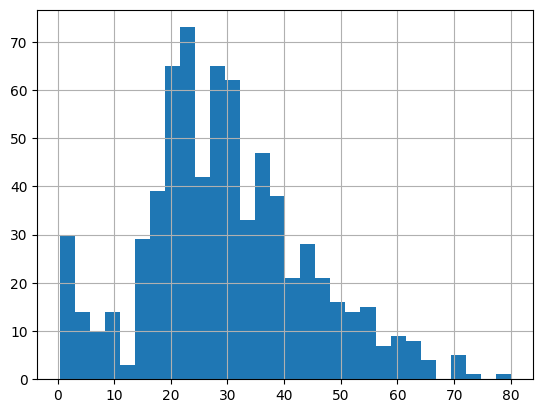

In [ ]:
df["Age"].hist(bins=30)


Age:
-Distribution is slightly right-skewed
- Median and mean are close so not extremely skewed
-  There are babies (0.42 years)
We can use median for inputation.

Lets handle missing values

In [18]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing


deck           77.104377
Cabin          77.104377
Age            19.865320
Embarked        0.224467
embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Name            0.000000
Pclass          0.000000
Ticket          0.000000
Parch           0.000000
SibSp           0.000000
Sex             0.000000
survived        0.000000
Fare            0.000000
sex             0.000000
pclass          0.000000
dtype: float64

In [20]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Age"].isna().sum()

np.int64(0)

In [21]:
df.drop(columns=["Cabin"], inplace=True)
df["deck"] = df["deck"].fillna("Unknown")
df["deck"] = df["deck"].astype("category")


In [24]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])


In [25]:
df.isna().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
survived       0
pclass         0
sex            0
embarked       0
deck           0
dtype: int64

Feature engineering

In [32]:
df["title"] = df["Name"].str.extract(r",\s*(\w+)\.")
df["title"].value_counts()

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Jonkheer      1
Name: count, dtype: int64

In [38]:
rare_titles = ["Lady", "the Countess", "Capt", "Col", "Don", "Dr", "Major",
               "Rev", "Sir", "Jonkheer", "Dona", "Ms", "Mme"]

df["title"] = df["title"].replace(rare_titles, "Rare")
df["title"].value_counts()

title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       24
Mlle        2
Name: count, dtype: int64

In [42]:
df["title"] = df["title"].fillna("Rare").astype("category")


In [39]:
df["family_size"] = df["SibSp"] + df["Parch"] + 1
df["family_size"].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

In [29]:
df["is_alone"] = (df["family_size"] == 1).astype(int)
df["is_alone"].value_counts()

is_alone
1    537
0    354
Name: count, dtype: int64

In [43]:
categorical_cols = ["Sex", "Embarked", "Pclass", "deck", "title"]
for col in categorical_cols:
    df[col] = df[col].astype("category")
df["title"] = df["title"].dropna().astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    str     
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    str     
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
 11  survived     891 non-null    bool    
 12  pclass       891 non-null    category
 13  sex          891 non-null    category
 14  embarked     891 non-null    category
 15  deck         891 non-null    category
 16  title        891 non-null    category
 17  family_size  891 non-null    int64   
 18  is_alone     891 non-null    int64   
dty

## ANALYSING PART

<Axes: >

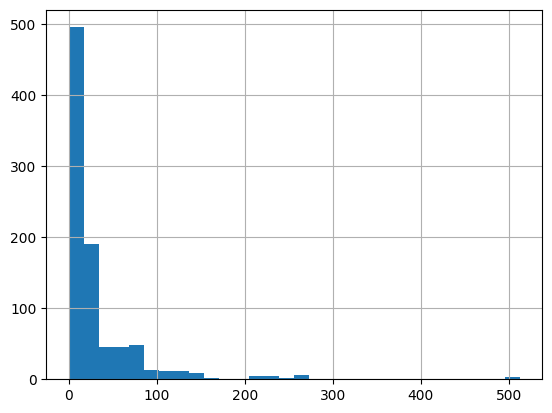

In [50]:
df["Fare"].hist(bins=30)



We'll do log transformation so that:
Distribution becomes more symmetric
Outliers compressed
Spread is more balanced

<Axes: >

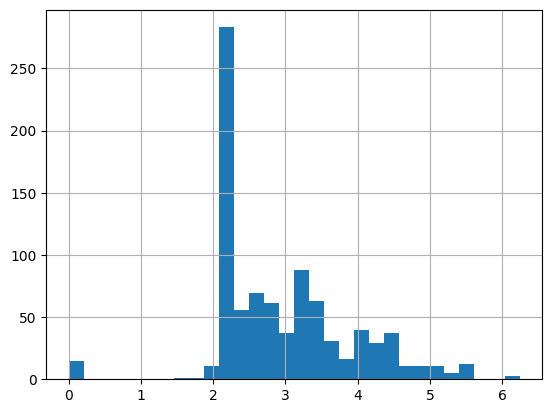

In [51]:
import numpy as np
df["fare_log"] = np.log1p(df["Fare"])
df["fare_log"].hist(bins=30)


In [ ]:
df.groupby("sex")["survived"].mean() # more women survived due to priority in evacuation


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [ ]:
df.groupby("pclass")["survived"].mean() # higher class had better chances of survival due to proximity to lifeboats and priority in evacuation


pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

In [ ]:
df["age_group"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

df.groupby("age_group")["survived"].mean() # children had higher survival rates due to priority in evacuation, while seniors had lower rates due to mobility issues and health conditions


age_group
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: survived, dtype: float64

In [ ]:
df.groupby("family_size")["survived"].mean() # larger families had lower survival rates due to difficulties in coordinating evacuation and limited lifeboat space


family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64

In [58]:
df["family_category"] = pd.cut(
    df["family_size"],
    bins=[0,1,4,10],
    labels=["Alone","Small Family","Large Family"]
)

df.groupby("family_category")["survived"].mean()


family_category
Alone           0.303538
Small Family    0.578767
Large Family    0.181818
Name: survived, dtype: float64

In [ ]:
df.groupby("deck")["survived"].mean() # decks A and B had higher survival rates due to proximity to lifeboats, while lower decks had lower rates due to flooding and difficulty in evacuation


deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: survived, dtype: float64

## Training model of survival prediction

In [ ]:
df_model = df.copy()

df_model = df.copy()
df_model.columns = df_model.columns.str.lower()
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

df_model["survived"] = df_model["survived"].astype(int)



In [85]:
df_model = df_model.drop(columns=["name", "ticket", "passengerid"])
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop(columns=["survived"])
y = df_model["survived"]


In [86]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [87]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [88]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)


0.8156424581005587

Our model has a 81% accuracy score. Lets look closely to features importance. If coefficient positive - it increases survival productivity.

In [ ]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients
# deck E and D, title Miss are the most positive predictors of survival, while having large family and being in lower classes  or Deck G are negative predictors.


,Feature,Coefficient
15,deck_E,1.182263
5,is_alone,0.743502
14,deck_D,0.706443
23,title_Mrs,0.698931
29,family_category_Small Family,0.554079
12,deck_B,0.422470
7,pclass_2,0.408559
6,fare_log,0.273261
28,age_group_Senior,0.123959
21,title_Mlle,0.060626


Lets look at correlation matrix of these features to "survived"

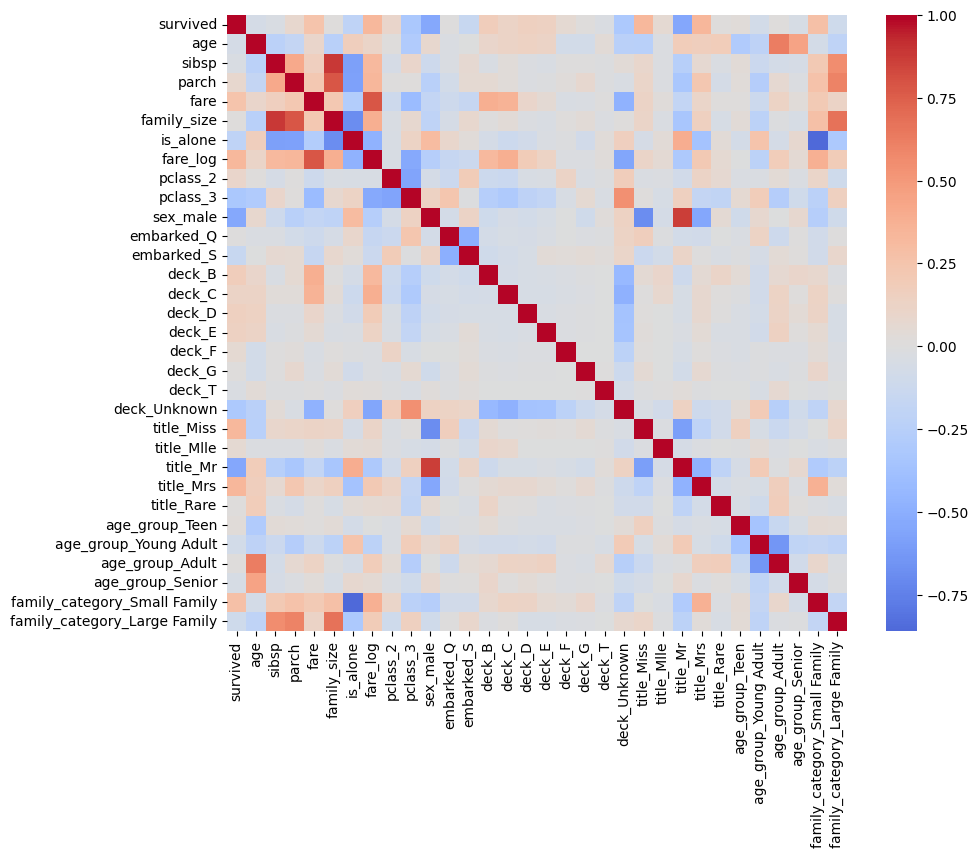

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_model.corr(), cmap="coolwarm", center=0)
plt.show()
# fare_log, age and family_size have the strongest correlation with survival, while some categorical features like title and deck also show moderate correlation.
# Being male or 3rd class reduces survival probability, while being in higher class and female increases it.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

'''
TN = 89 - correctly predicted non-survivors

FP = 16 - predicted survived but actually died

FN = 17 - predicted died but actually survived

TP = 57 - correctly predicted survivors

Model correctly identifies most non-survivor and many survivors (slightly less) due to class imbalance.



Of all passengers the model predicted would survive,
78% actually survived. So about 22% were false positives.

Of all passengers who actually survived,
77% were correctly identified. So about 23% were false negatives.

With non survivors being the majority class, the model is better at identifying them (high TN) than survivors (lower TP), 
which is common in imbalanced datasets.

'''

[[89 16]
 [17 57]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84       105
           1       0.78      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



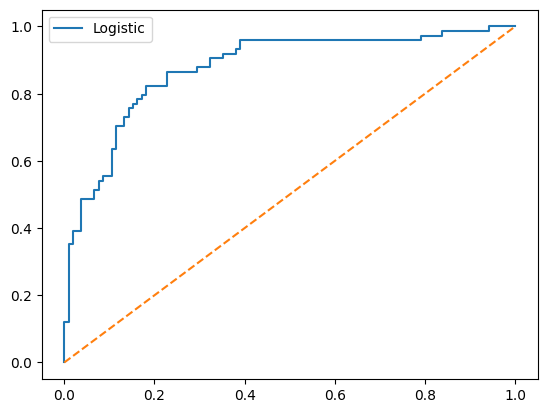

Logistic AUC: 0.8760617760617759


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic ROC
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

print("Logistic AUC:", roc_auc_score(y_test, y_prob))
#The model will correctly rank the survivor higher 87.6% of the time, which indicates good discriminative ability.
# curve is above the diagonal, showing better performance than random guessing.


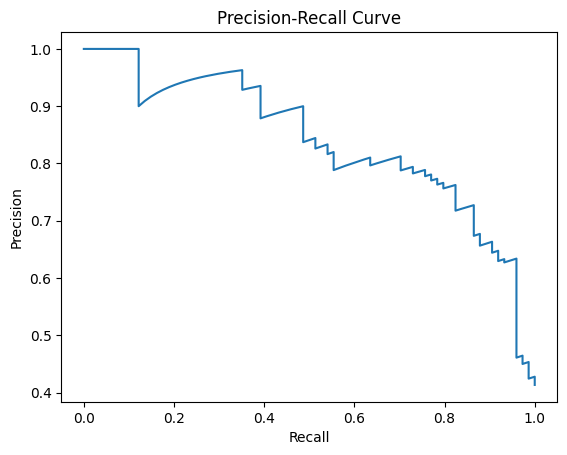

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall") #Of all actual positive items, how many did the model identify?
plt.ylabel("Precision") #Of all items predicted as positive, how many were actually positive?
plt.title("Precision-Recall Curve")
plt.show()

# When threshold is very high we predict very few survivors, so precision is high but recall is low. 
# As we lower the threshold, we predict more survivors, increasing recall but decreasing precision due to more false positives.

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]


Random Forest:
- Better predictive power
- Less interpretable
- Handles complexity
- Handles nonlinear relationships

In [ ]:
print(classification_report(y_test, y_pred_rf))
roc_auc_score(y_test, y_prob_rf)

print("RF AUC:", roc_auc_score(y_test, y_prob_rf))
''' Slightly better AUC

Similar accuracy

Similar precision/recall
'''

              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179

RF AUC: 0.8897683397683398


In [ ]:
# Train accuracy
y_train_pred_rf = rf.predict(X_train)
train_acc_rf = accuracy_score(y_train, y_train_pred_rf)

# Test accuracy
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print("RF Train Accuracy:", train_acc_rf)
print("RF Test Accuracy:", test_acc_rf)
''' The train accuracy is higher than the test accuracy, which may indicate some overfitting, 
but the test accuracy is still good, so the model generalizes reasonably well.'''

RF Train Accuracy: 0.9845505617977528
RF Test Accuracy: 0.8156424581005587


In [ ]:
print("Logistic AUC:", roc_auc_score(y_test, y_prob))
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))
# The AUC is slightly higher for the Random Forest, indicating it has a better ability to discriminate between survivors 
# and non-survivors compared to Logistic Regression.

Logistic AUC: 0.8760617760617759
RF AUC: 0.8897683397683398
